# 08 The phone-number shortcut: diagnose, fix, combine (E10-E12)

1. **E10 diagnose:** minimal pairs that change one placeholder (`python -m src.stress`).
2. **E11 fix:** number-balanced counterfactual training (`--variant counterfactual`).
3. **E12 combine:** char LR OR AfroXLMR, plain or number-balanced, chosen on validation (`python -m src.ensemble`).
4. **Significance:** paired bootstrap (`python -m src.significance`).

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../.cache/mpl'))
import pandas as pd
from IPython.display import Image, Markdown, display
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 200)
from src import config
S = pd.read_csv(config.RESULTS / 'experiments.csv')          # mean (and sd) over seeds
BY_SEED = pd.read_csv(config.RESULTS / 'experiments_by_seed.csv')

def table(models, sets, variant='clean', split='template', metric='f1'):
    t = S[S.model.isin(models) & S.set.isin(sets) & (S.variant == variant) & (S.split == split)]
    return t.pivot_table(index='model', columns='set', values=metric).reindex(models).round(3)

## E10: what one placeholder does

The genuine test texts get ` <PHONE>` appended; the 48 test scams that contain a placeholder lose it. Nothing else changes, so every flip is caused by the number.

In [2]:
stress = pd.read_csv(config.RESULTS / 'stress_tests.csv')
cols = ['model', 'variant', 'false_alarm_clean', 'false_alarm_+phone', 'false_alarm_+amount', 'miss_clean', 'miss_-number', 'n_seeds']
stress[stress.variant.isin(['clean', 'counterfactual'])][cols].round(3)

,model,variant,false_alarm_clean,false_alarm_+phone,false_alarm_+amount,miss_clean,miss_-number,n_seeds
0,afroxlmr,clean,0.000,0.962,0.653,0.000,0.201,3
1,afroxlmr,counterfactual,0.000,0.000,0.005,0.000,0.021,3
3,bilstm_finetuned,clean,0.000,0.277,0.038,0.000,0.021,3
4,bilstm_finetuned,counterfactual,0.000,0.000,0.019,0.000,0.000,3
7,bilstm_frozen,clean,0.019,0.174,0.099,0.000,0.014,3
8,bilstm_random,clean,0.009,0.695,0.038,0.000,0.007,3
9,ensemble,clean,0.000,0.962,0.653,0.000,0.021,3
10,ensemble_cf,clean,0.000,0.155,0.089,0.000,0.021,3
11,ensemble_cf2,clean,0.014,0.014,0.061,0.000,0.021,3
12,ensemble_mean,clean,0.000,0.817,0.451,0.000,0.118,3


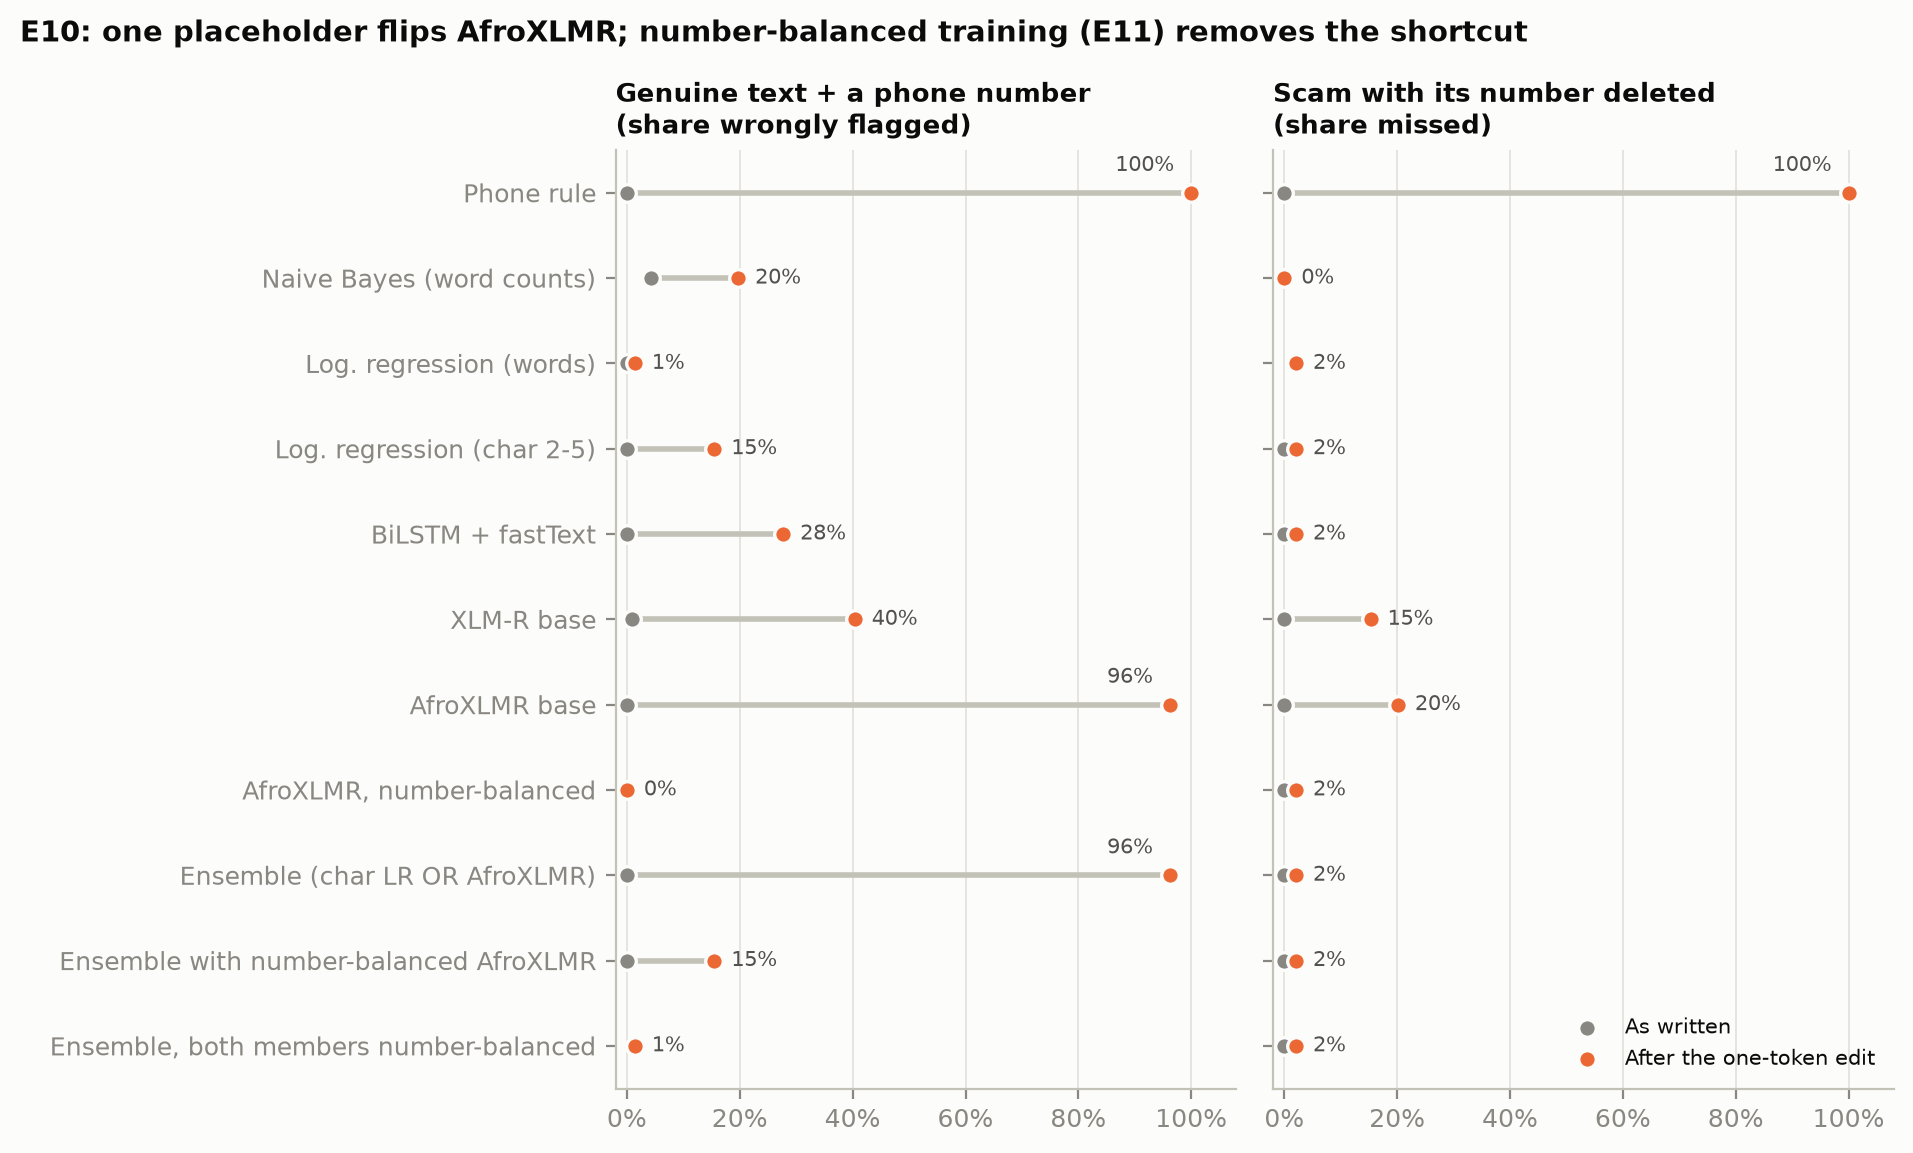

In [3]:
display(Image(str(config.FIGURES / 'e10_stress_tests.png')))

In [4]:
ev = pd.read_csv(config.DATA_PROCESSED / 'eval_template.csv', keep_default_na=False)
ex = ev[ev.set == 'stress_genuine+phone'].head(3)
for t in ex.text: print(t)

Chukua maua yako <PHONE>
Hiyo stori uliyoniambia jana bado inanishangaza! Hahaha. <PHONE>
Naomba uniunganishe na rafiki yako. <PHONE>


**Reading.** Appending a phone number to a genuine chat message makes AfroXLMR call it a scam 96% of the time (XLM-R 40%, BiLSTM 28%, NB 20%, char LR 15%, word LR 1%), and deleting the number from a scam makes AfroXLMR miss 20%. The two transformers, which have the same size, differ sharply, so capacity alone does not predict how strongly a model takes the shortcut.

## E11: number-balanced counterfactual training

In training, half of the scams that carry a placeholder lose it and each genuine text gets ` <PHONE>` appended with probability 0.4, so a number appears in about 44% of scams and 38% of genuine texts. Words and labels are untouched; validation and test are not edited.

In [5]:
from src.variants import number_balanced
from src.data import load_bongo, split_frames
train, _, _ = split_frames(load_bongo(), 'template')
edited, info = number_balanced(train[['text', 'label']])
info

{'edited_rows': 318,
 'edited_share': 0.41842105263157897,
 'number_share_scam': 0.4419753086419753,
 'number_share_genuine': 0.37746478873239436}

In [6]:
sets = ['test', 'test/tpl', 'test_lookalike_all', 'test_structural_all', 'test_codeswitch_all', 'chichewa/all']
t = S[S.model.isin(['lr_char', 'bilstm_finetuned', 'afroxlmr']) & S.variant.isin(['clean', 'counterfactual']) & S.set.isin(sets)]
t.pivot_table(index=['model', 'variant'], columns='set', values='f1').round(3)

set                              chichewa/all  ...  test_structural_all
model            variant                       ...                     
afroxlmr         clean                  0.719  ...                0.898
                 counterfactual         0.716  ...                0.954
bilstm_finetuned clean                  0.750  ...                0.829
                 counterfactual         0.627  ...                0.961
lr_char          clean                  0.651  ...                0.763
                 counterfactual         0.146  ...                0.719

[6 rows x 6 columns]

**Reading.** Number-balanced training removes the shortcut for every model (AfroXLMR: 0% false alarms when a number is added, 2% misses when it is removed). For AfroXLMR it raises test PR-AUC (0.958 to 0.985; the F1 gain 0.78 to 0.82 is not significant, p = 0.06) with no loss under attack, but it lowers Chichewa precision (-0.06, p < 0.001) and makes the model flag disguised genuine texts more (24% with 3 words disguised, 75% with every word). For the char LR it costs resistance to lookalike letters (F1 0.73 to 0.50) and most of its Chichewa transfer (0.65 to 0.15); for the BiLSTM it removes the phone-number false alarms (28% to 0%) and helps against split words (0.83 to 0.96) but costs resistance to code-switching (0.76 to 0.66) and Chichewa F1 (0.75 to 0.63): for the classical models "contains a number" was what transferred.

## E12: the complementary ensemble

Flag a message when either the char LR or AfroXLMR flags it (each at its own validation threshold). Choosing which members to deploy uses only the validation stress pairs:

In [7]:
val_stress = config.RESULTS / 'stress_tests_validation.csv'
if val_stress.exists():
    v = pd.read_csv(val_stress)
    display(v[v.model.isin(['lr_char', 'afroxlmr', 'ensemble', 'ensemble_cf', 'ensemble_cf2'])][['model', 'variant', 'false_alarm_+phone', 'false_alarm_+amount', 'miss_-number']].round(3))

,model,variant,false_alarm_+phone,false_alarm_+amount,miss_-number
0,afroxlmr,clean,0.958,0.634,0.088
1,afroxlmr,counterfactual,0.000,0.000,0.000
9,ensemble,clean,0.958,0.634,0.000
10,ensemble_cf,clean,0.099,0.028,0.000
11,ensemble_cf2,clean,0.000,0.000,0.000
14,lr_char,advtrain,0.155,0.028,0.000
15,lr_char,clean,0.099,0.028,0.000
16,lr_char,counterfactual,0.000,0.000,0.000
17,lr_char,strip,0.000,0.000,0.000


In [8]:
systems = [('lr_char', 'clean'), ('lr_char', 'counterfactual'), ('afroxlmr', 'clean'), ('afroxlmr', 'counterfactual'), ('ensemble_mean', 'clean'), ('ensemble', 'clean'), ('ensemble_cf', 'clean'), ('ensemble_cf2', 'clean')]
rows = []
for m, v in systems:
    r = S[(S.model == m) & (S.variant == v) & S.set.isin(sets + ['chichewa/all'])]
    rows.append(r.pivot_table(index=['model', 'variant'], columns='set', values='f1'))
pd.concat(rows).round(3)

set                           chichewa/all  ...  test_structural_all
model         variant                       ...                     
lr_char       clean                  0.651  ...                0.763
              counterfactual         0.146  ...                0.719
afroxlmr      clean                  0.719  ...                0.898
              counterfactual         0.716  ...                0.954
ensemble_mean clean                  0.708  ...                0.819
ensemble      clean                  0.720  ...                0.898
ensemble_cf   clean                  0.737  ...                0.954
ensemble_cf2  clean                  0.715  ...                0.948

[8 rows x 6 columns]

**Reading.** The validation stress pairs (the only evidence used for this choice) favour the ensemble with both members number-balanced: 0% false alarms and 0% misses, against 10% false alarms with a plain char LR and 96% with a plain AfroXLMR. On test (reported, not used to choose) it scores F1 0.994 and keeps 0.95-0.99 under lookalike and split-word attacks from either attacker, +0.18 to +0.23 over the char LR (p < 0.001 in the three comparisons tested). The mean rule fails because AfroXLMR's probabilities sit at 0 or 1. On two fresh splits the deployed ensemble scores 0.994 and 0.988: well above AfroXLMR (+0.20 to +0.22, p < 0.001) and level with the char LR (+0.02 to +0.03, not significant), so its clean-text advantage over the char LR is small; its value is robustness to disguise and to the number shortcut.

In [9]:
t = S[S.model.isin(['lr_char', 'afroxlmr', 'ensemble_mean', 'ensemble', 'ensemble_cf', 'ensemble_cf2']) & S.split.isin(['template', 'template_r1', 'template_r2']) & (S.set == 'test')]
t.pivot_table(index=['model', 'variant'], columns='split', values='f1').round(3)

split                         template  template_r1  template_r2
model         variant                                           
afroxlmr      advtrain           0.763          NaN          NaN
              clean              0.776        0.791        0.763
              counterfactual     0.820        0.907        0.767
              strip              0.798          NaN          NaN
ensemble      clean              0.968        0.975        0.968
ensemble_cf   clean              0.968        0.981        0.962
ensemble_cf2  clean              0.994        0.994        0.988
ensemble_mean clean              0.782        0.800        0.763
lr_char       advtrain           0.962          NaN          NaN
              clean              0.968        0.975        0.962
              counterfactual     0.988        1.000        0.988
              nomask             0.994          NaN          NaN
              repeat             0.972          NaN          NaN
              strip              0.975          NaN          NaN

## Are the differences real?

In [10]:
pd.read_csv(config.RESULTS / 'significance.csv').round(4)

,comparison,metric,difference,ci_low,ci_high,p_value,seed_pairs,test
0,"AfroXLMR vs XLM-R, Chichewa ranking",pr_auc,0.1503,0.0803,0.2435,0.0000,3,paired bootstrap
1,"AfroXLMR vs XLM-R, Chichewa F1",f1,0.0017,-0.0408,0.0438,0.9483,3,paired bootstrap
2,"AfroXLMR vs XLM-R, Swahili test F1",f1,0.0160,0.0000,0.0647,0.3870,3,paired bootstrap
3,"Plain ensemble (char LR OR AfroXLMR) vs AfroXLMR, Swahili test F1",f1,0.1926,0.1179,0.2800,0.0000,3,paired bootstrap
4,"Plain ensemble vs char LR, full lookalike attack F1",f1,0.2310,0.1422,0.3284,0.0000,3,paired bootstrap
5,"Plain ensemble vs char LR, full structural attack F1",f1,0.1351,0.0480,0.2547,0.0000,3,paired bootstrap
6,"Normalisation vs none, word LR under full lookalike",f1,0.5175,0.4011,0.6364,0.0000,1,paired bootstrap
7,"Normalisation vs none, word LR under held-out lookalikes",f1,0.0000,0.0000,0.0000,1.0000,1,paired bootstrap
8,"Number-balanced vs clean AfroXLMR, Chichewa F1",f1,-0.0025,-0.0498,0.0340,0.9927,3,paired bootstrap
9,"Number-balanced vs clean AfroXLMR, Chichewa precision",precision,-0.0643,-0.1216,-0.0242,0.0000,3,paired bootstrap
